In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from collections import Counter
pd.set_option('display.precision', 3)
from pandas import read_csv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn import preprocessing
from pandas.plotting import scatter_matrix
from scipy.stats import boxcox
from statsmodels.genmod.generalized_linear_model import GLM
from sklearn.model_selection import train_test_split

In [3]:
wifi = pd.read_csv('../data/raw/train_nt.csv', header=0, delimiter=';')
X_test_nolabels = pd.read_csv('../data/raw/test_nolabels_nt.csv', header=0, delimiter=';')
wifi.shape

(12888, 262)

In [4]:
wifi.head()

,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
0,0,0,-5703,-88,-88,0,0,4,5,7,...,-13,6,-13,-2,-8,3,-12,1,-12,9
1,1,0,1835,-91,-88,0,0,-10,4,-7,...,-7,-11,-9,-18,-7,-8,-8,-8,-10,9
2,2,0,4,-86,-87,0,0,5,14,5,...,10,7,16,7,13,11,16,11,13,9
3,3,52464,1259,-81,-71,0,0,-1,12,1,...,13,-7,14,-6,17,-6,16,-7,16,2
4,4,0,900,-82,-76,0,0,9,2,9,...,6,14,4,16,7,14,7,14,2,2


In [5]:
wifi.describe()

,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
count,12888.000,12888.000,12888.000,12888.000,12888.000,12888.0,12888.0,12888.000,12888.000,12888.000,...,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000
mean,6443.500,16008.410,15.017,-78.052,-77.952,0.0,0.0,-0.406,-0.478,-0.500,...,-0.402,-0.355,-0.296,-0.328,-0.295,-0.311,-0.269,-0.241,-0.363,4.493
std,3720.589,19829.509,3087.311,6.805,8.349,0.0,0.0,10.209,10.123,10.416,...,10.549,10.407,10.520,11.013,11.160,11.075,11.248,11.018,11.118,2.871
min,0.000,0.000,-8703.000,-97.000,-94.000,0.0,0.0,-25.000,-26.000,-24.000,...,-25.000,-25.000,-26.000,-32.000,-38.000,-25.000,-26.000,-27.000,-31.000,0.000
25%,3221.750,0.000,-1751.000,-83.000,-84.000,0.0,0.0,-10.000,-10.000,-10.000,...,-10.000,-10.000,-10.000,-10.000,-10.000,-11.000,-11.000,-10.000,-11.000,2.000
50%,6443.500,5464.000,-30.000,-80.000,-80.000,0.0,0.0,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.000
75%,9665.250,29424.000,1798.000,-74.000,-71.000,0.0,0.0,9.000,9.000,9.000,...,9.000,9.000,9.000,10.000,10.000,10.000,10.000,10.000,10.000,7.000
max,12887.000,65520.000,8915.000,-58.000,-58.000,0.0,0.0,25.000,25.000,23.000,...,23.000,29.000,23.000,33.000,35.000,25.000,25.000,26.000,26.000,9.000


In [6]:
wifi.dtypes

ID          int64
seq_ctrl    int64
aoa         int64
rssi1       int64
rssi2       int64
            ...  
I62_2       int64
Q62_2       int64
I63_2       int64
Q63_2       int64
position    int64
Length: 262, dtype: object

In [7]:
print(wifi.isnull().values.any()) # no hay supuestos NA
print((wifi == " ").sum().sum())
print((wifi == "").sum().sum())

False
0
0


Si nos fijamos en la descripción del dataset, seq_ctrl: uint16 sequence numbers. Por lo tanto, seq_ctrl [0,2^16 -1] = [0, 65535].
Los últimos números se guardan para detectar errores?


In [8]:
print((wifi["seq_ctrl"] >= 65520).sum().sum()) #posibles errores

3


In [9]:
print(wifi["position"].value_counts())

position
1    1488
5    1397
8    1312
7    1278
9    1273
4    1249
3    1237
6    1230
2    1224
0    1200
Name: count, dtype: int64


array([<Axes: title={'center': 'seq_ctrl'}>], dtype=object)

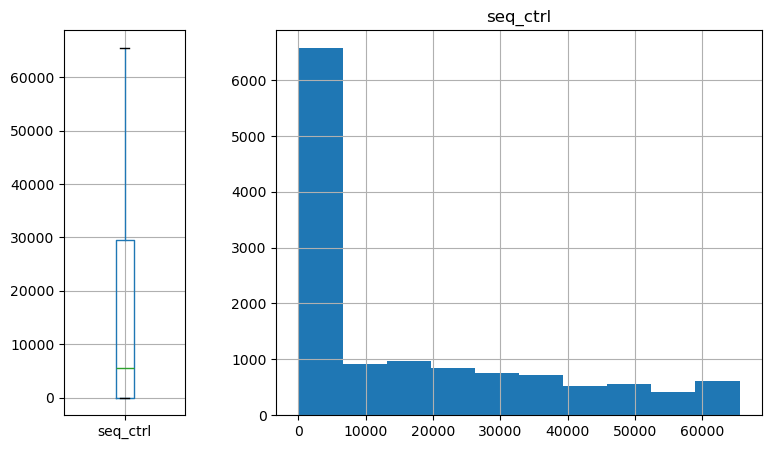

In [10]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='seq_ctrl',ax=axes[0])
wifi.hist(column='seq_ctrl', ax=axes[1])

array([<Axes: title={'center': 'aoa'}>], dtype=object)

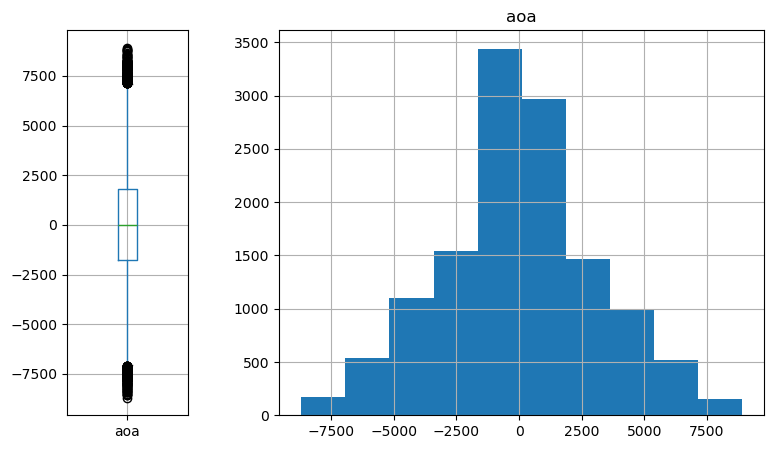

In [11]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='aoa',ax=axes[0])
wifi.hist(column='aoa', ax=axes[1])

array([<Axes: title={'center': 'rssi1'}>], dtype=object)

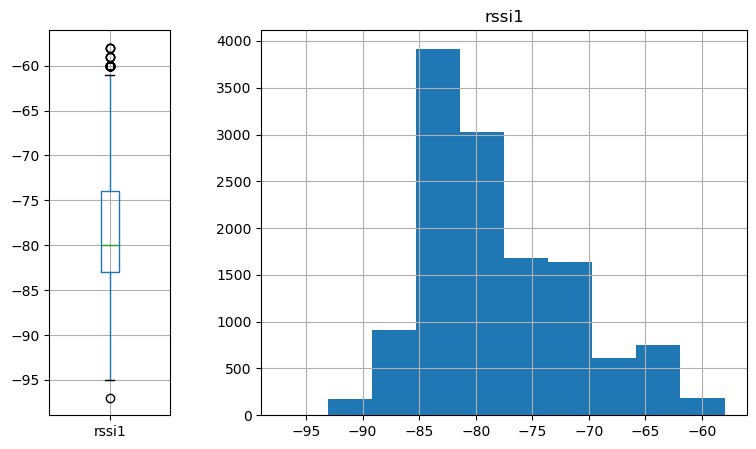

In [12]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='rssi1',ax=axes[0])
wifi.hist(column='rssi1', ax=axes[1])

array([<Axes: title={'center': 'rssi2'}>], dtype=object)

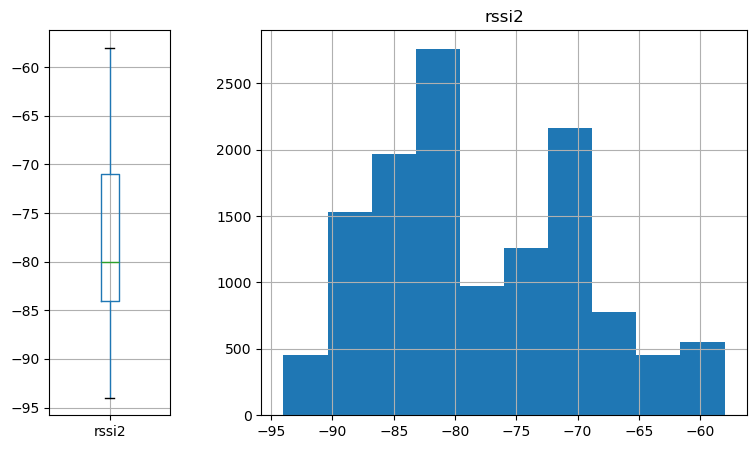

In [13]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='rssi2',ax=axes[0])
wifi.hist(column='rssi2', ax=axes[1])

In [14]:
y, X = wifi['position'], wifi.drop('position', axis=1)

# NUEVAS VARIABLES

In [15]:
import pandas as pd
import numpy as np

def create_features(X: pd.DataFrame) -> pd.DataFrame:
    # 1. DEFINICIÓN DE VARIABLES BASE
    # Eliminamos 'seq_ctrl' por ser ruido temporal.
    base_features = ['aoa', 'rssi1', 'rssi2']
    
    # Subportadoras útiles (estándar 802.11)
    valid_subs = [n for n in range(64) if n not in {0, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37}]

    # Diccionarios para acumular nuevas columnas de forma eficiente
    new_features_dict = {}
    
    # Listas para organizar grupos de columnas
    iq_cols = []
    diff_cols = []

    # 2. PROCESAMIENTO POR ANTENA Y SUBPORTADORA
    for antena in [1, 2]:
        for n in valid_subs:
            # Nombres de tus columnas originales
            i_col = f"I{n}_{antena}"
            q_col = f"Q{n}_{antena}"
            
            if i_col in X.columns and q_col in X.columns:
                # Extraemos I y Q
                I_val = X[i_col]
                Q_val = X[q_col]
                
                # Guardamos I y Q como features principales
                iq_cols.append(i_col)
                iq_cols.append(q_col)
                
                # Calculamos Magnitud y Fase (necesarias para Diffs y Stats)
                mag_val = np.sqrt(I_val**2 + Q_val**2)
                phase_val = np.arctan2(Q_val, I_val)
                
                # Las guardamos temporalmente en el diccionario para usarlas luego
                new_features_dict[f"tmp_mag{n}_{antena}"] = mag_val
                new_features_dict[f"tmp_phase{n}_{antena}"] = phase_val

    # Unimos temporalmente para facilitar cálculos grupales
    X_tmp = pd.concat([X, pd.DataFrame(new_features_dict, index=X.index)], axis=1)

    # 3. CÁLCULO DE DIFERENCIAS DE FASE (La "Brújula" de posición)
    phase_diff_dict = {}
    for n in valid_subs:
        p1 = f"tmp_phase{n}_1"
        p2 = f"tmp_phase{n}_2"
        if p1 in X_tmp.columns and p2 in X_tmp.columns:
            diff = X_tmp[p1] - X_tmp[p2]
            # Normalización circular entre -pi y pi
            phase_diff_dict[f"phase_diff{n}"] = np.arctan2(np.sin(diff), np.cos(diff))
    
    diff_cols = list(phase_diff_dict.keys())
    X_tmp = pd.concat([X_tmp, pd.DataFrame(phase_diff_dict, index=X_tmp.index)], axis=1)

    # 4. ESTADÍSTICAS DE ENERGÍA (Resumen de potencia por antena)
    stats_dict = {}
    for antena in [1, 2]:
        m_cols = [f"tmp_mag{n}_{antena}" for n in valid_subs if f"tmp_mag{n}_{antena}" in X_tmp.columns]
        if m_cols:
            mags = X_tmp[m_cols].values
            stats_dict[f"mean_mag_{antena}"] = mags.mean(axis=1)
            stats_dict[f"total_energy_{antena}"] = np.sum(mags**2, axis=1)
            stats_dict[f"std_mag_{antena}"] = mags.std(axis=1)

    X_tmp = pd.concat([X_tmp, pd.DataFrame(stats_dict, index=X_tmp.index)], axis=1)

    # 5. SELECCIÓN FINAL: RSSI + I + Q + Phase_Diffs + Stats
    final_features = base_features + iq_cols + diff_cols + list(stats_dict.keys())
    
    # Filtramos solo las que existen y descartamos las columnas constantes
    X_final = X_tmp[[c for c in final_features if c in X_tmp.columns]].copy()
    
    const_cols = [col for col in X_final.columns if X_final[col].nunique() <= 1]
    X_final = X_final.drop(columns=const_cols)
    
    print(f"Dataset listo para posición. Features: {X_final.shape[1]}")
    
    return X_final

X_new = create_features(X)
X_test_nolabels = create_features(X_test_nolabels)

X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)


Dataset listo para posición. Features: 269
Dataset listo para posición. Features: 269


In [16]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(10310, 269) (10310,)
(2578, 269) (2578,)


# OUTLIER DETECTION  (aoa, rssi1, rssi2) 

## aoa

array([<Axes: title={'center': 'aoa'}>], dtype=object)

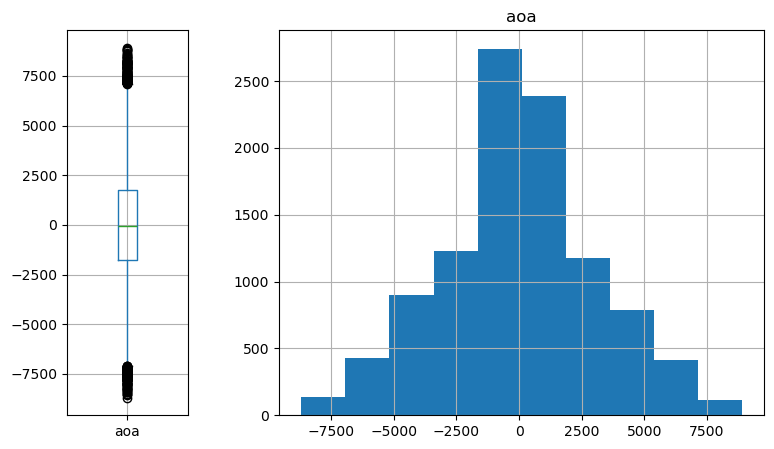

In [18]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train.boxplot(column='aoa',ax=axes[0])
X_train.hist(column='aoa', ax=axes[1])

In [19]:
local_outlier_factor = LocalOutlierFactor(n_neighbors=20)
result = local_outlier_factor.fit_predict(X_train['aoa'].values.reshape(-1, 1))

outliers = result == -1
no_outliers = result == 1

Counter(result)

C:\Users\dijor\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Counter({np.int64(1): 10254, np.int64(-1): 56})

array([<Axes: title={'center': 'aoa'}>], dtype=object)

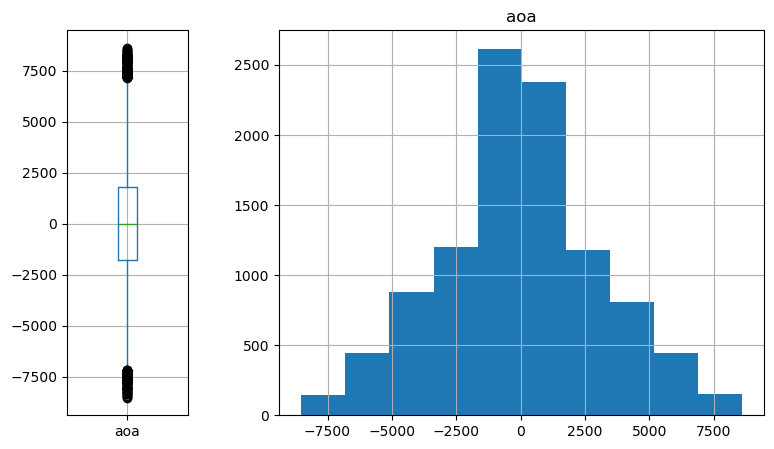

In [20]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train[no_outliers].boxplot(column='aoa',ax=axes[0])
X_train[no_outliers].hist(column='aoa', ax=axes[1])

In [21]:
X_train_filtered = X_train[no_outliers]
y_train_filtered = y_train[no_outliers]

In [22]:
X_train_filtered.shape, y_train_filtered.shape

((10254, 269), (10254,))

## rssi1

array([<Axes: title={'center': 'rssi1'}>], dtype=object)

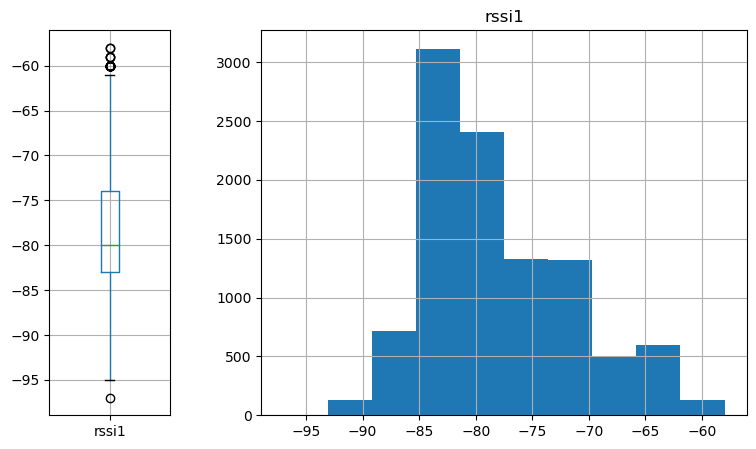

In [23]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.boxplot(column='rssi1',ax=axes[0])
X_train_filtered.hist(column='rssi1', ax=axes[1])

In [24]:
local_outlier_factor = LocalOutlierFactor(n_neighbors=20)
result = local_outlier_factor.fit_predict(X_train_filtered['rssi1'].values.reshape(-1, 1))

outliers = result == -1
no_outliers = result == 1

Counter(result)

C:\Users\dijor\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Counter({np.int64(1): 10228, np.int64(-1): 26})

array([<Axes: title={'center': 'rssi1'}>], dtype=object)

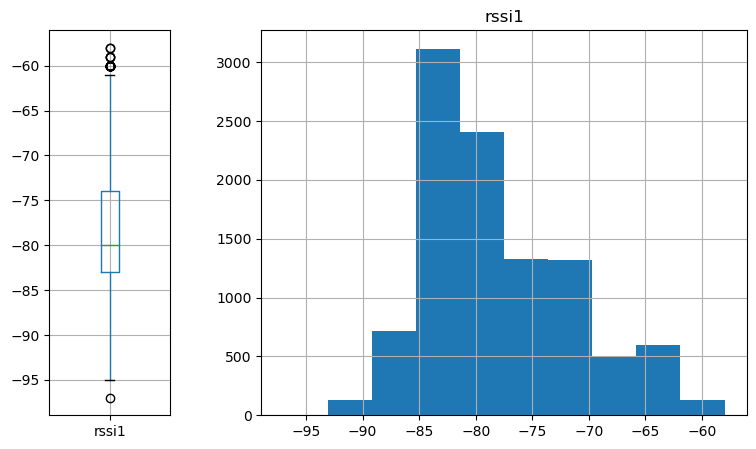

In [25]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.boxplot(column='rssi1',ax=axes[0])
X_train_filtered.hist(column='rssi1', ax=axes[1])

In [26]:
X_train_filtered = X_train_filtered[no_outliers]
y_train_filtered = y_train_filtered[no_outliers]

In [27]:
X_train_filtered.shape, y_train_filtered.shape

((10228, 269), (10228,))

## rssi2

array([<Axes: title={'center': 'rssi2'}>], dtype=object)

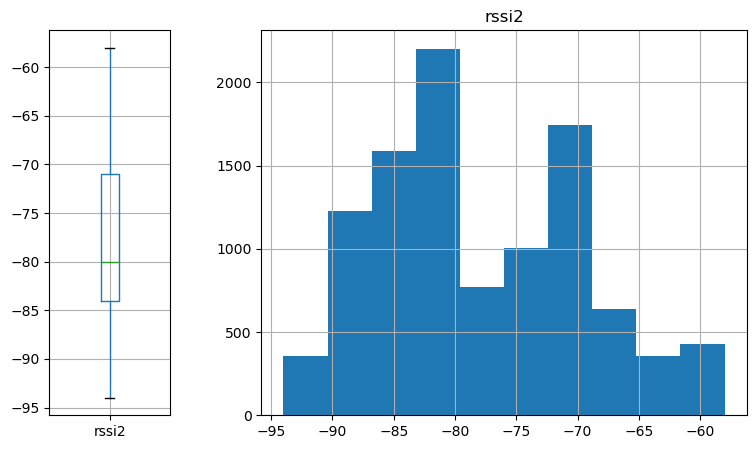

In [28]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.boxplot(column='rssi2',ax=axes[0])
X_train.hist(column='rssi2', ax=axes[1])

In [29]:
local_outlier_factor = LocalOutlierFactor(n_neighbors=20)
result = local_outlier_factor.fit_predict(X_train_filtered['rssi2'].values.reshape(-1, 1))

outliers = result == -1
no_outliers = result == 1

Counter(result)

C:\Users\dijor\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Counter({np.int64(1): 10210, np.int64(-1): 18})

array([<Axes: title={'center': 'rssi2'}>], dtype=object)

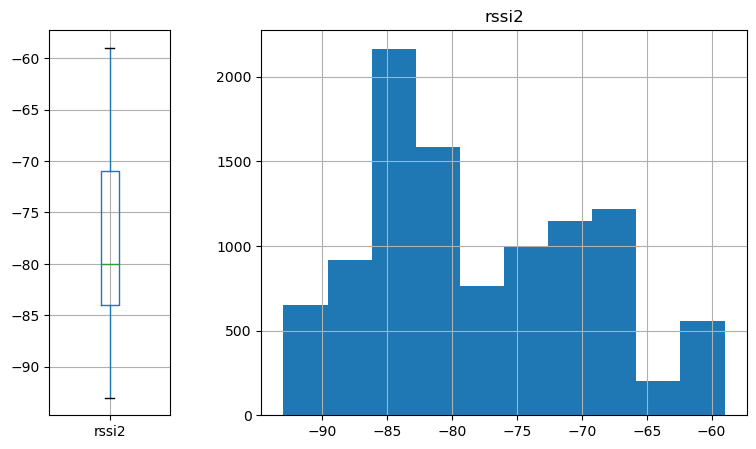

In [30]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered[no_outliers].boxplot(column='rssi2',ax=axes[0])
X_train_filtered[no_outliers].hist(column='rssi2', ax=axes[1])

In [31]:
X_train_filtered = X_train_filtered[no_outliers]
y_train_filtered = y_train_filtered[no_outliers]


print(X_train_filtered.shape, y_train_filtered.shape)


(10210, 269) (10210,)


In [32]:
print(X_train_filtered.shape, y_train_filtered.shape)

(10210, 269) (10210,)


In [34]:
def plot_feature_histograms(df: pd.DataFrame, n_cols_grid: int = 5, bins: int = 40,
                             by_class: bool = False, class_col: str = "position",
                             output_dir: str = None):
    """
    Visualiza histogramas de todas las features en cuadrículas 5x5.

    Parámetros
    ----------
    df         : DataFrame con las features (y opcionalmente la columna de clase)
    n_cols_grid: columnas por fila (default 5 → cuadrícula 5x5)
    bins       : bins del histograma
    by_class   : si True, colorea cada clase por separado
    class_col  : nombre de la columna de clase (default "position")
    output_dir : si se indica, guarda los PNGs en esa carpeta en vez de mostrarlos
    """
    import math
    from pathlib import Path

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    feature_cols = [c for c in df.columns if c != class_col]
    n_per_page   = n_cols_grid ** 2
    output_path  = Path(output_dir) if output_dir else None
    if output_path:
        output_path.mkdir(parents=True, exist_ok=True)

    for page_start in range(0, len(feature_cols), n_per_page):
        block  = feature_cols[page_start : page_start + n_per_page]
        n_rows = math.ceil(len(block) / n_cols_grid)
        page_n = page_start // n_per_page + 1

        fig, axes = plt.subplots(n_rows, n_cols_grid,
                                 figsize=(n_cols_grid * 3, n_rows * 2.4))
        axes = np.array(axes).flatten()
        fig.suptitle(f"Features — pág {page_n}", fontsize=13, fontweight="bold", y=1.01)

        for j, col in enumerate(block):
            ax = axes[j]
            if by_class and class_col in df.columns:
                for k, cls in enumerate(sorted(df[class_col].unique())):
                    ax.hist(df.loc[df[class_col] == cls, col].dropna(),
                            bins=bins, alpha=0.5,
                            color=colors[k % len(colors)], label=f"cls {cls}")
            else:
                ax.hist(df[col].dropna(), bins=bins,
                        color="steelblue", edgecolor="none", alpha=0.85)

            ax.set_title(col, fontsize=8, pad=3)
            ax.tick_params(labelsize=7)

        for k in range(len(block), len(axes)):
            axes[k].axis("off")

        plt.tight_layout()

        if output_path:
            fpath = output_path / f"features_p{page_n}.png"
            plt.savefig(fpath, dpi=120, bbox_inches="tight")
            plt.close()
        else:
            plt.show()
            plt.close()

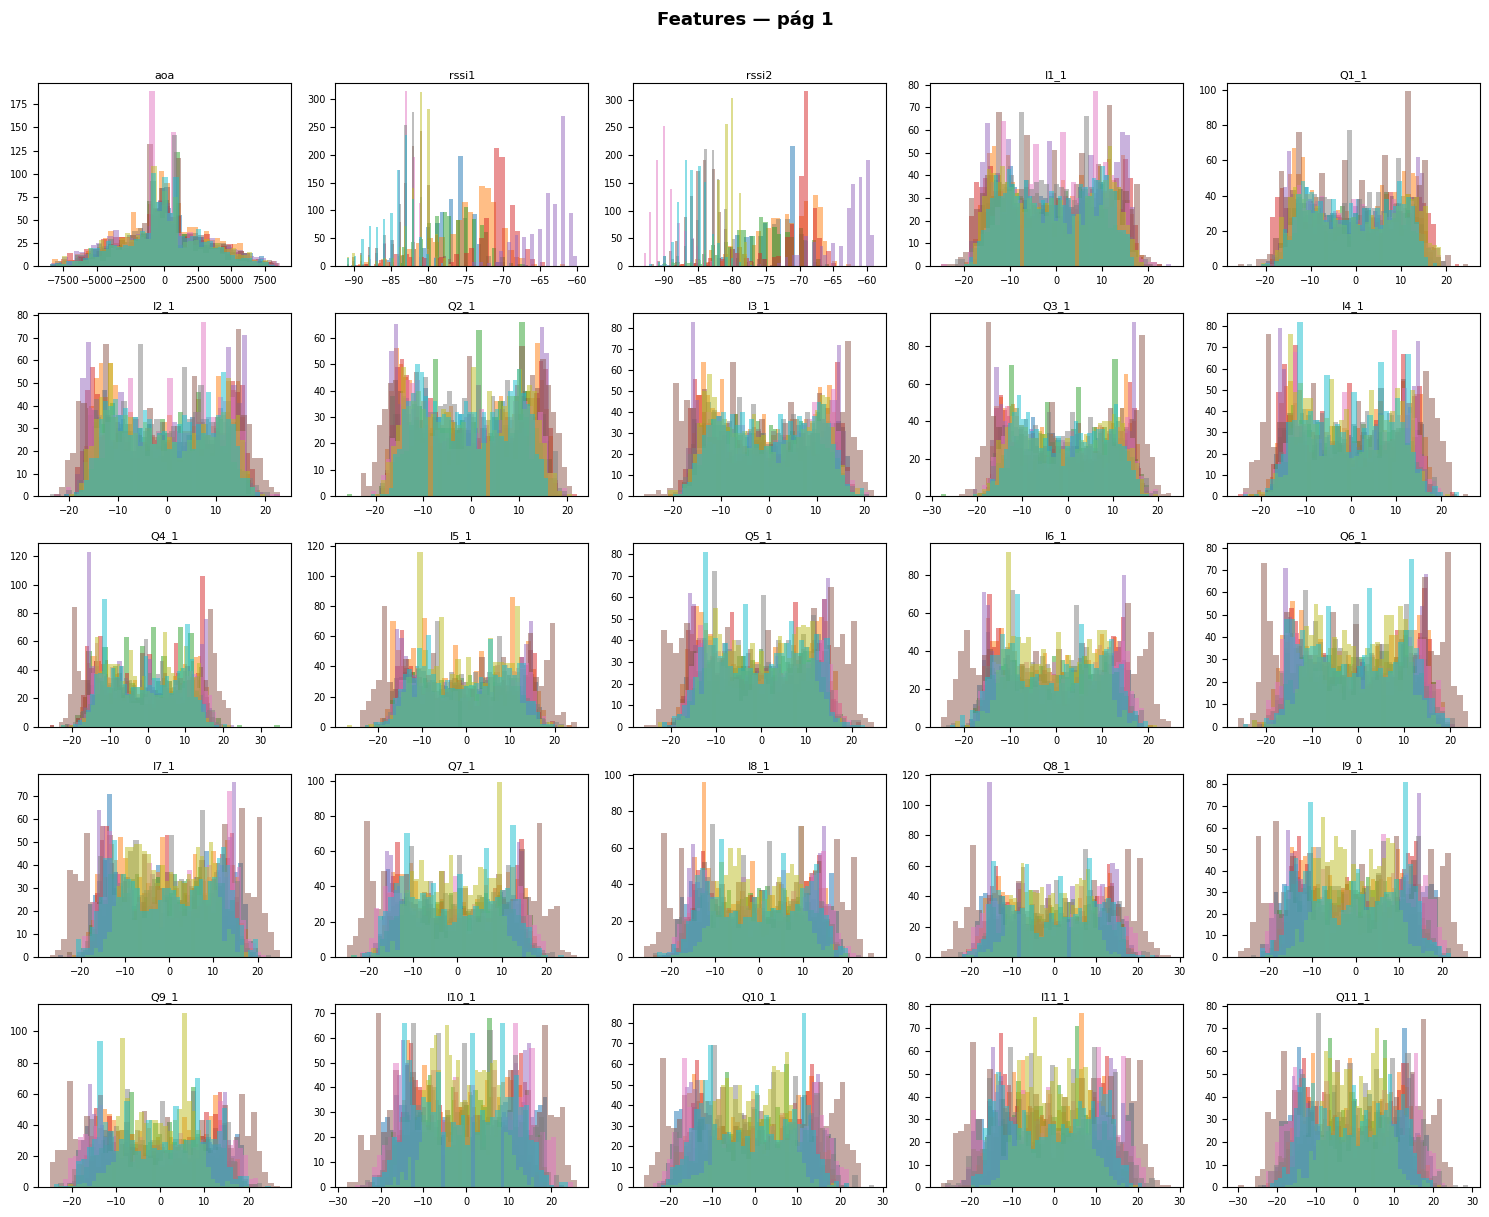

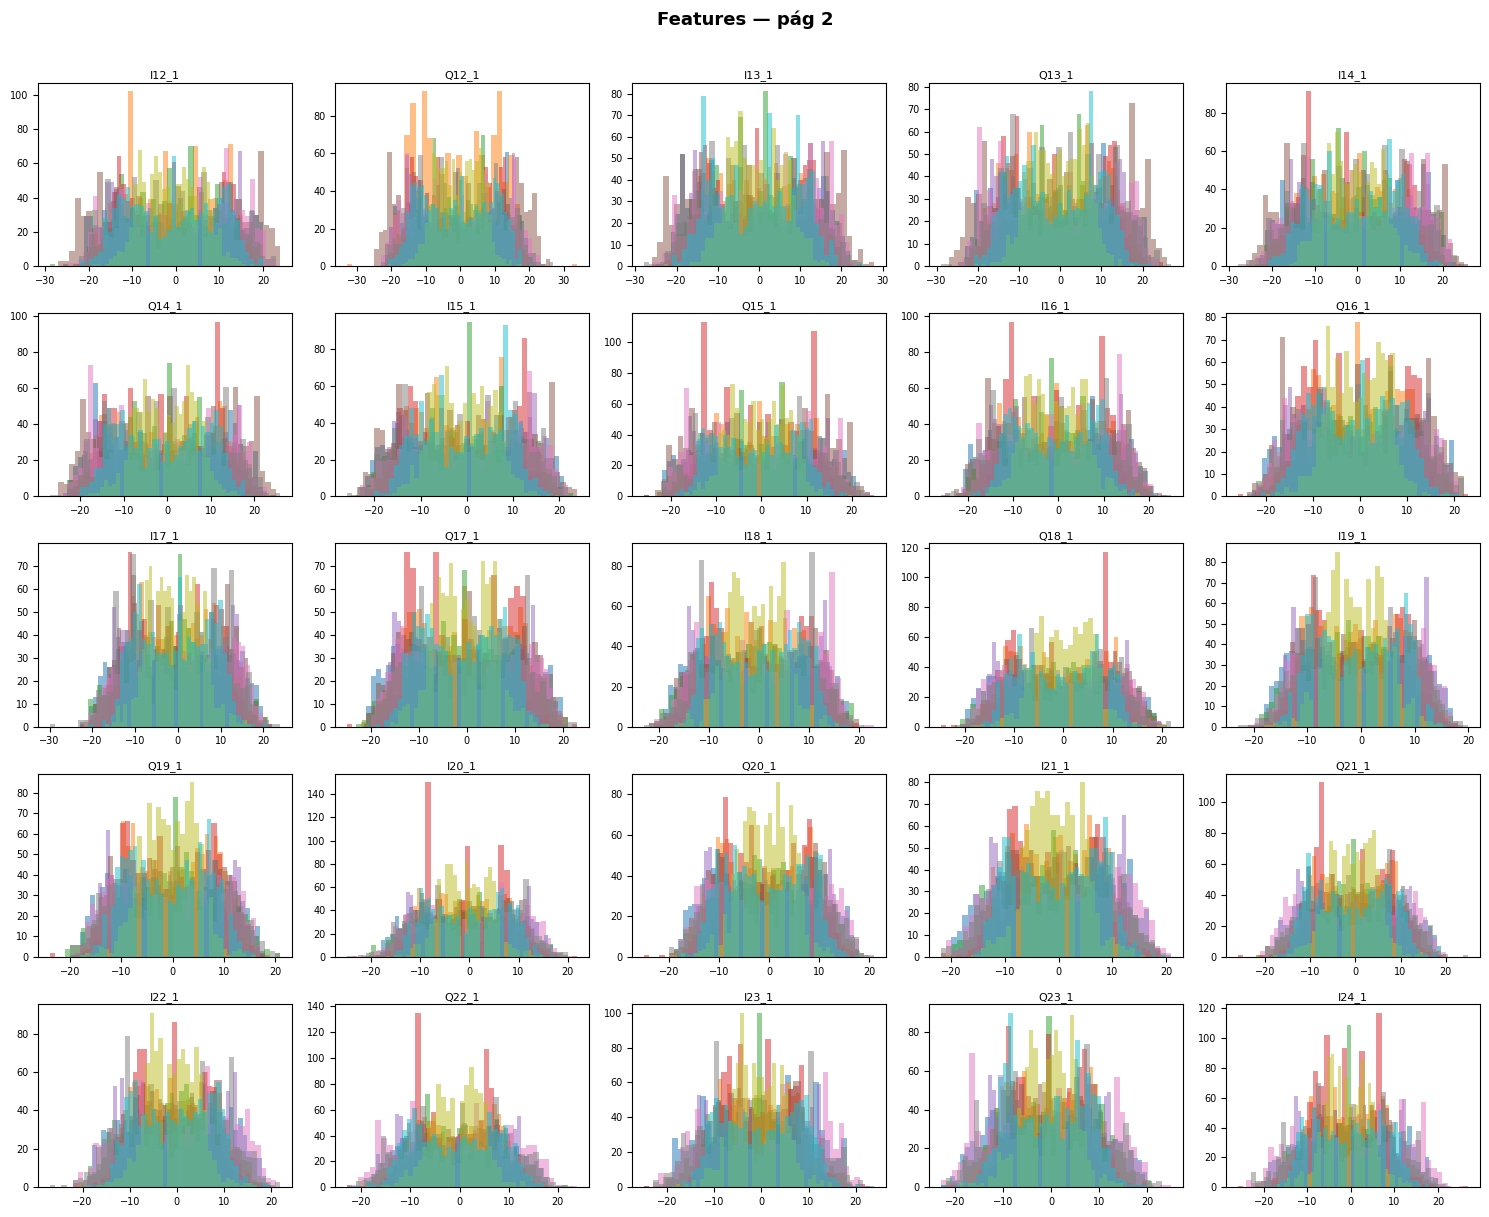

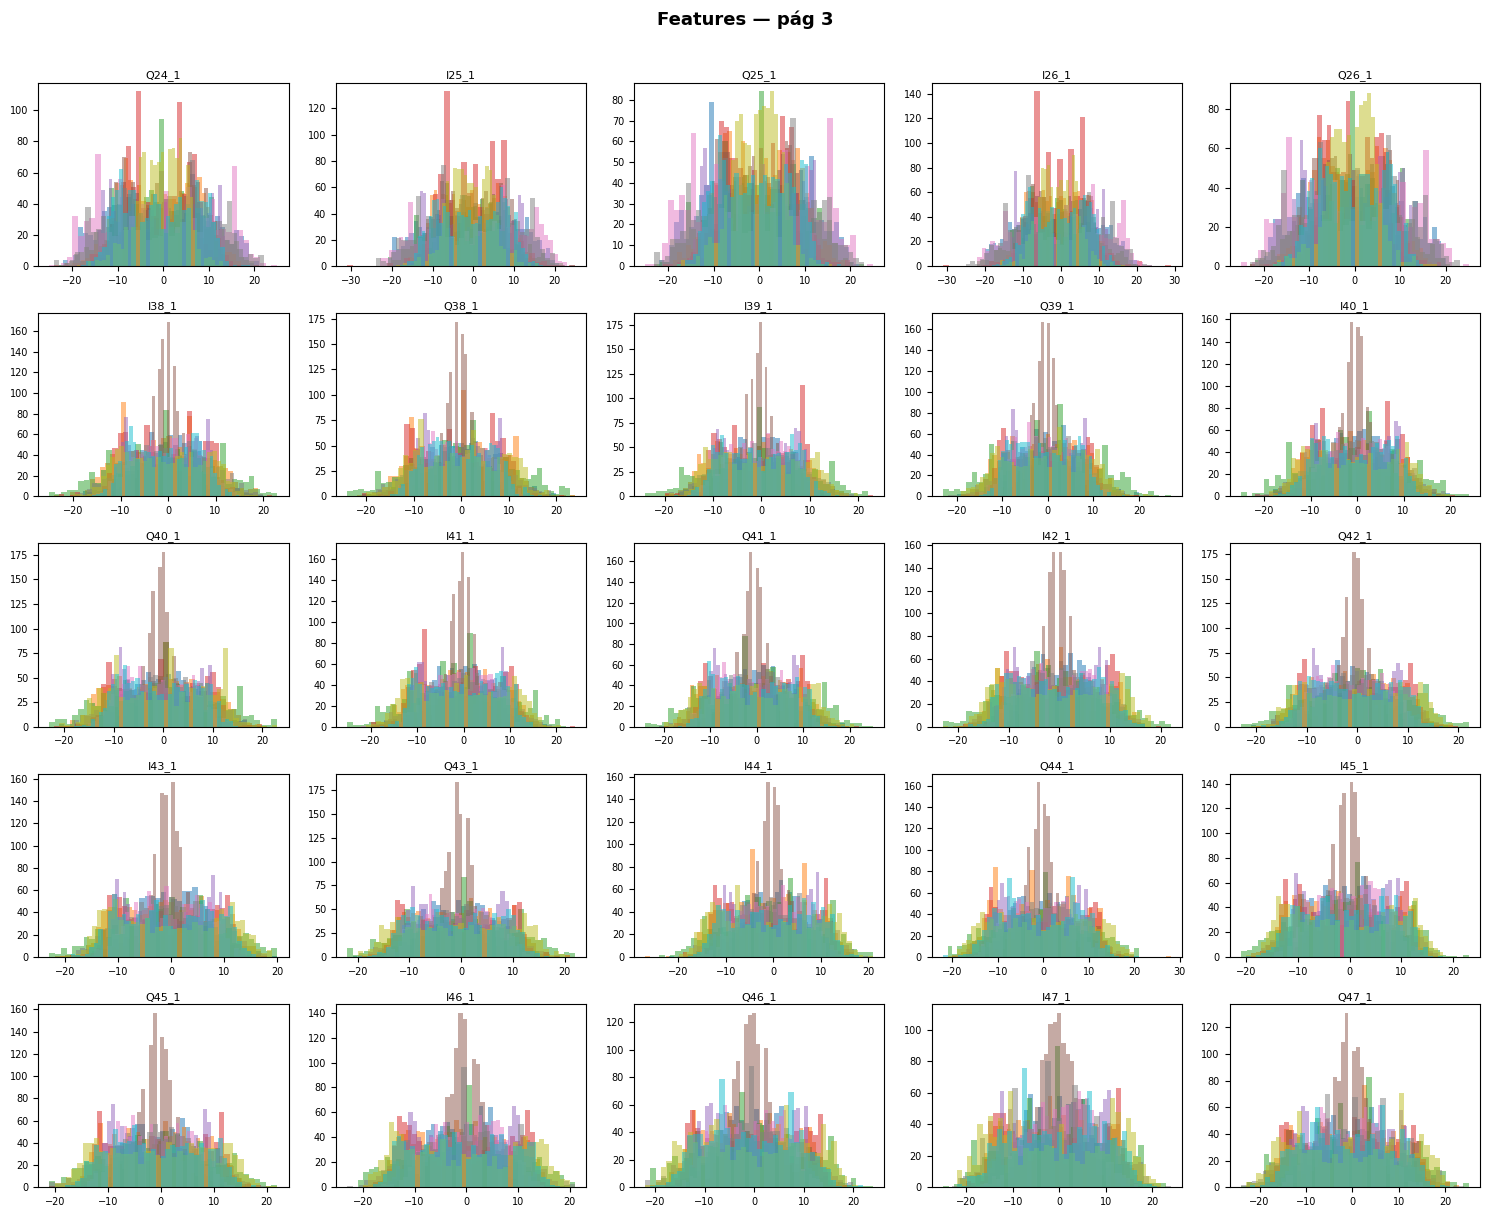

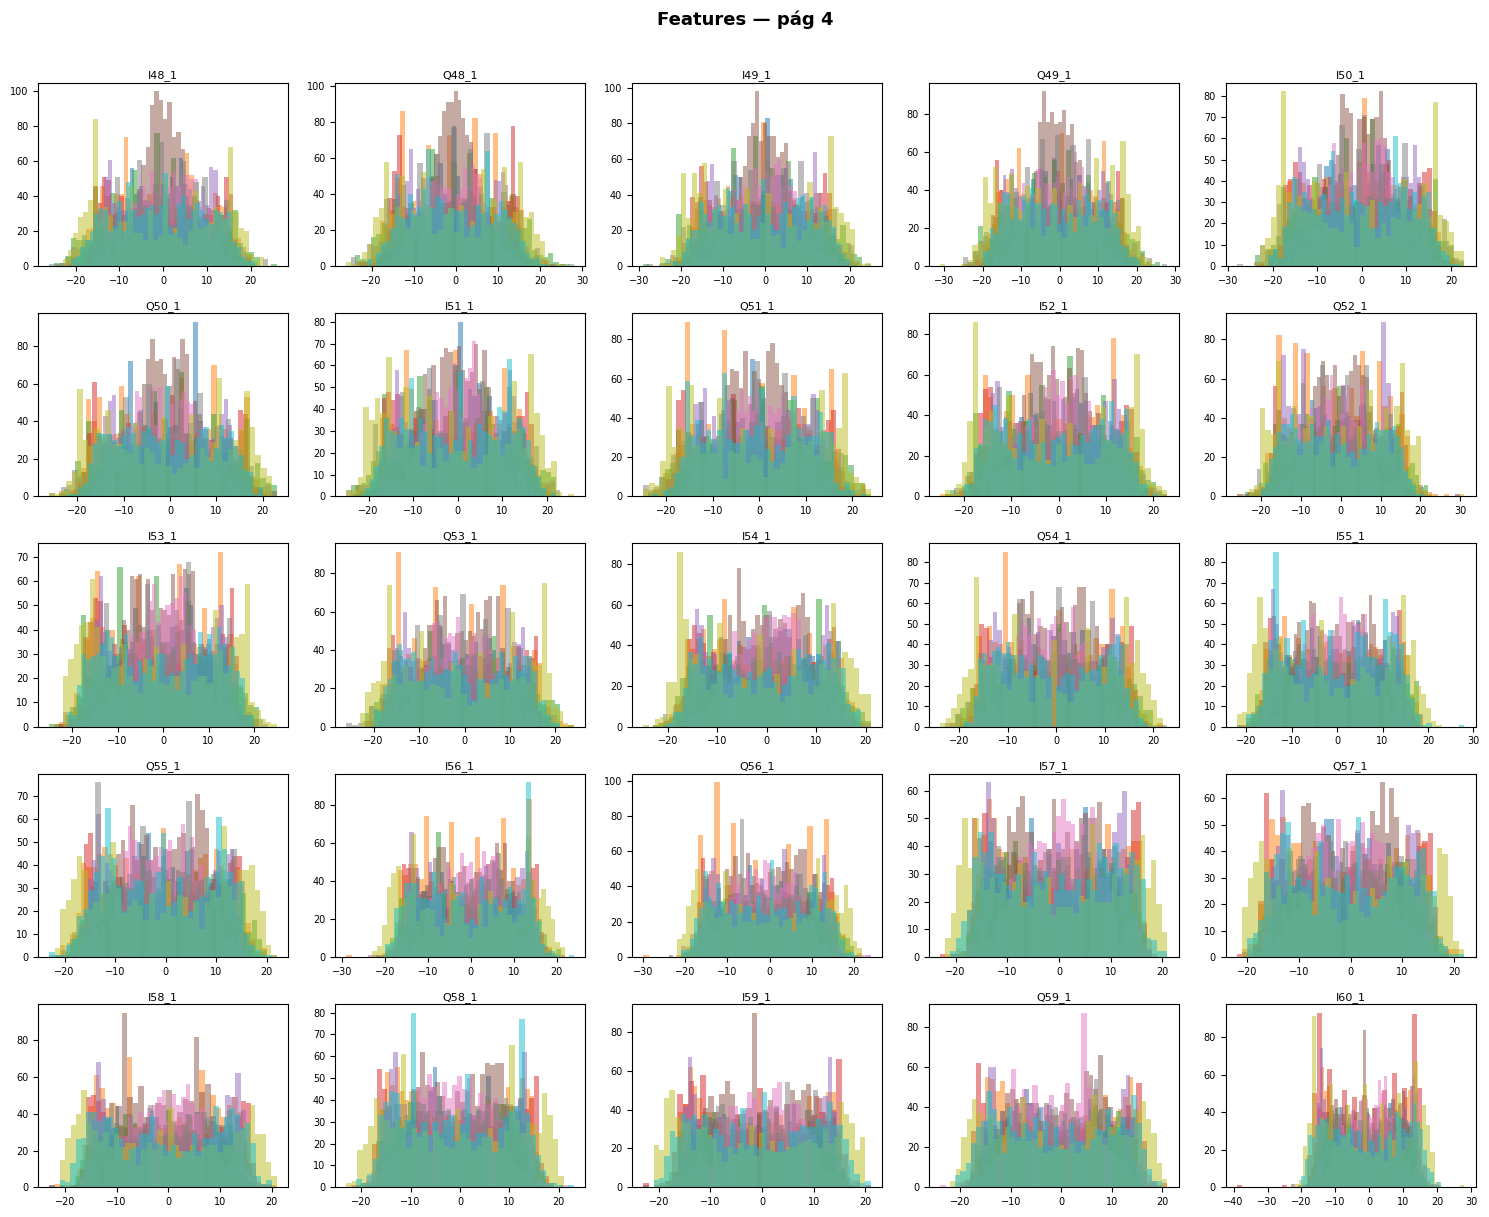

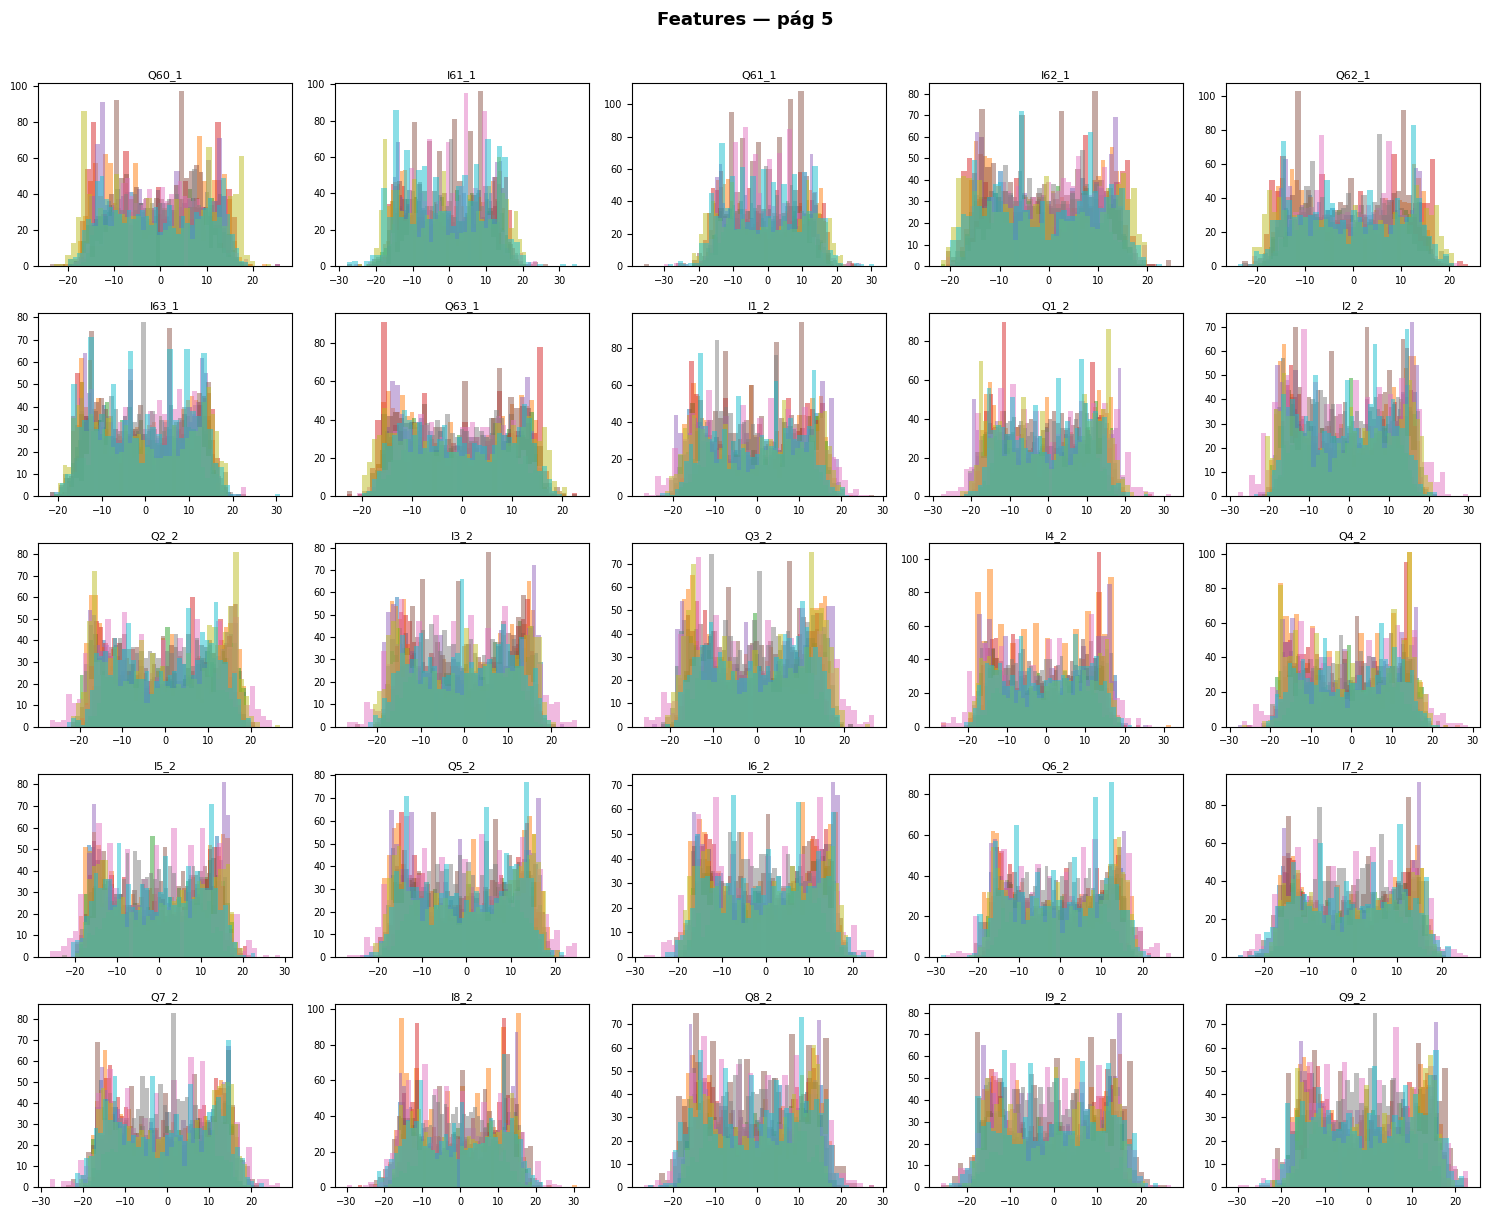

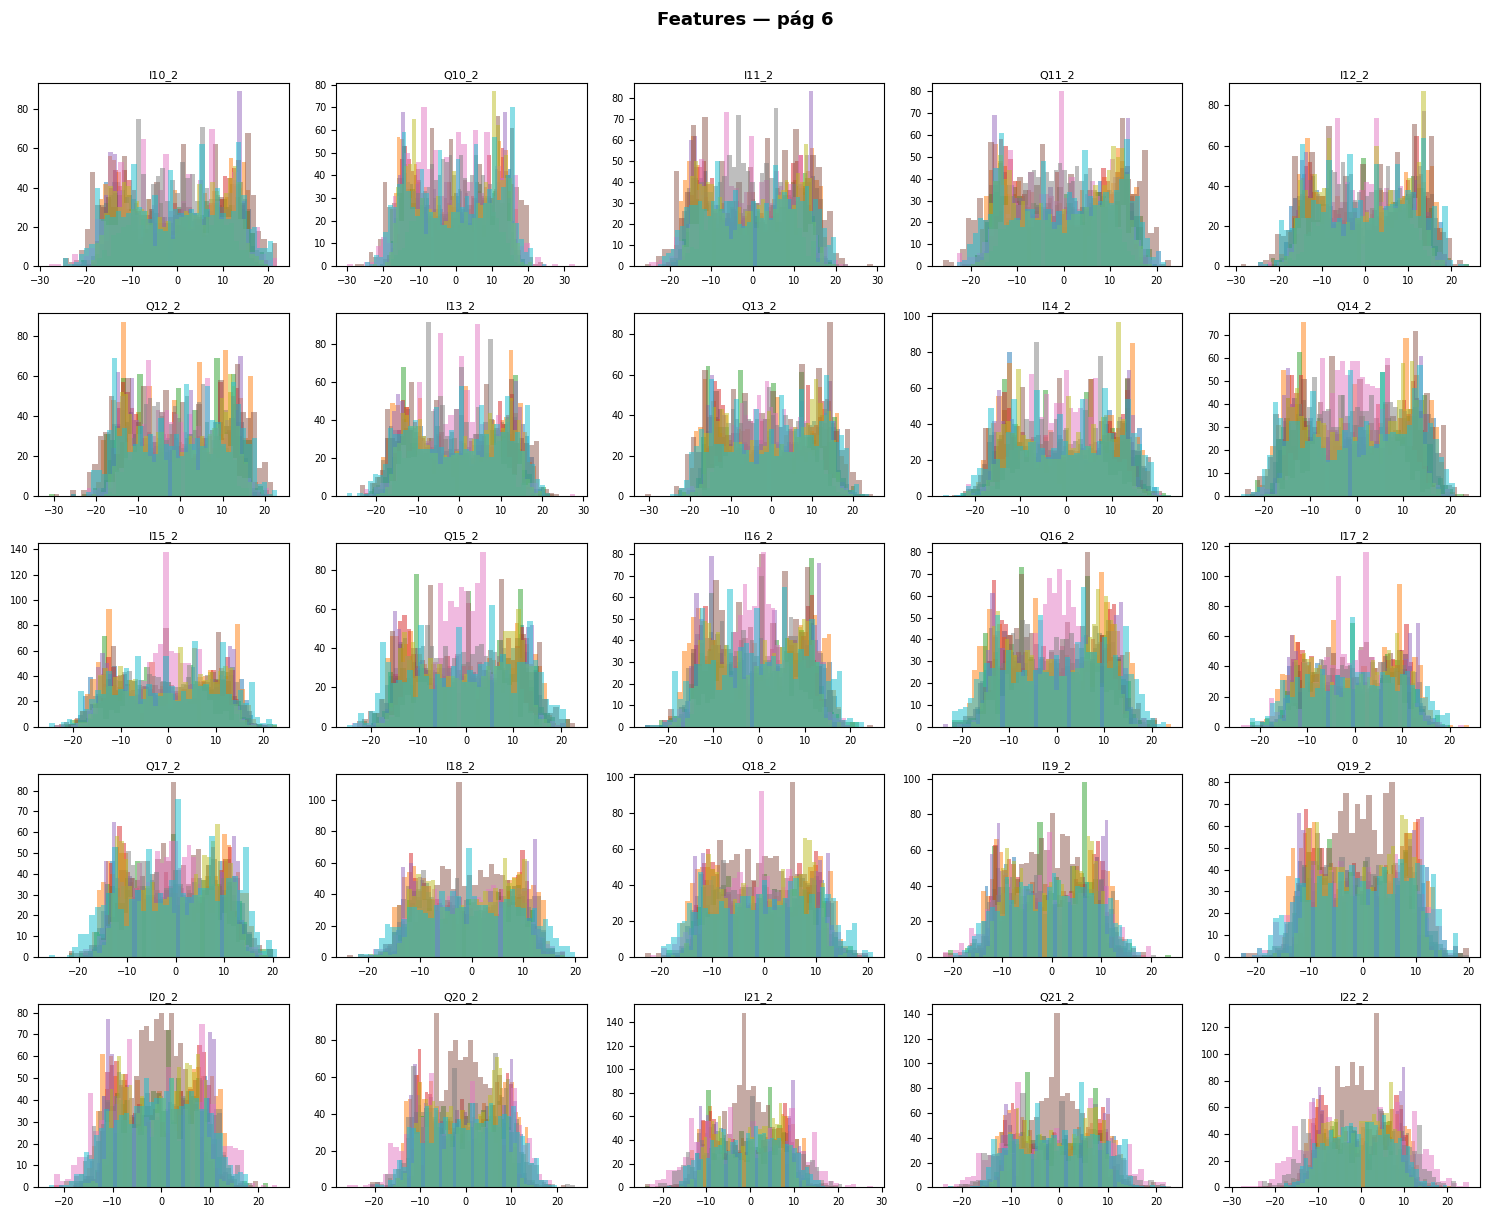

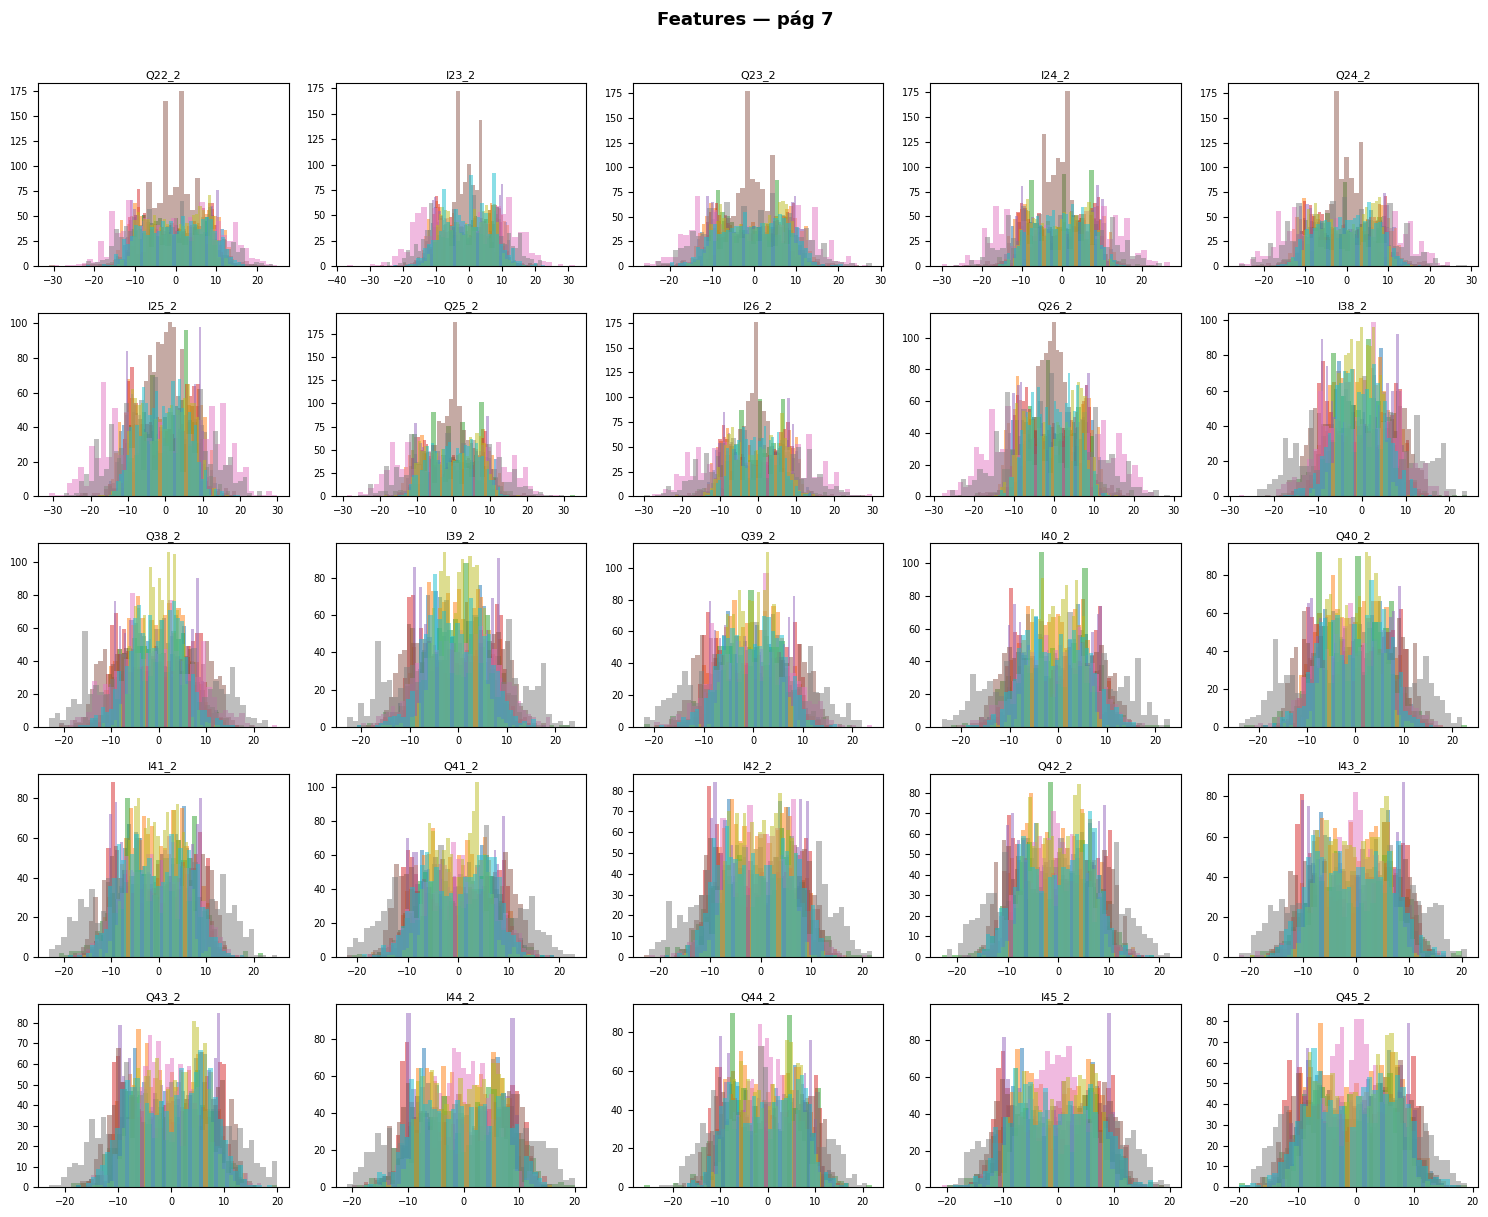

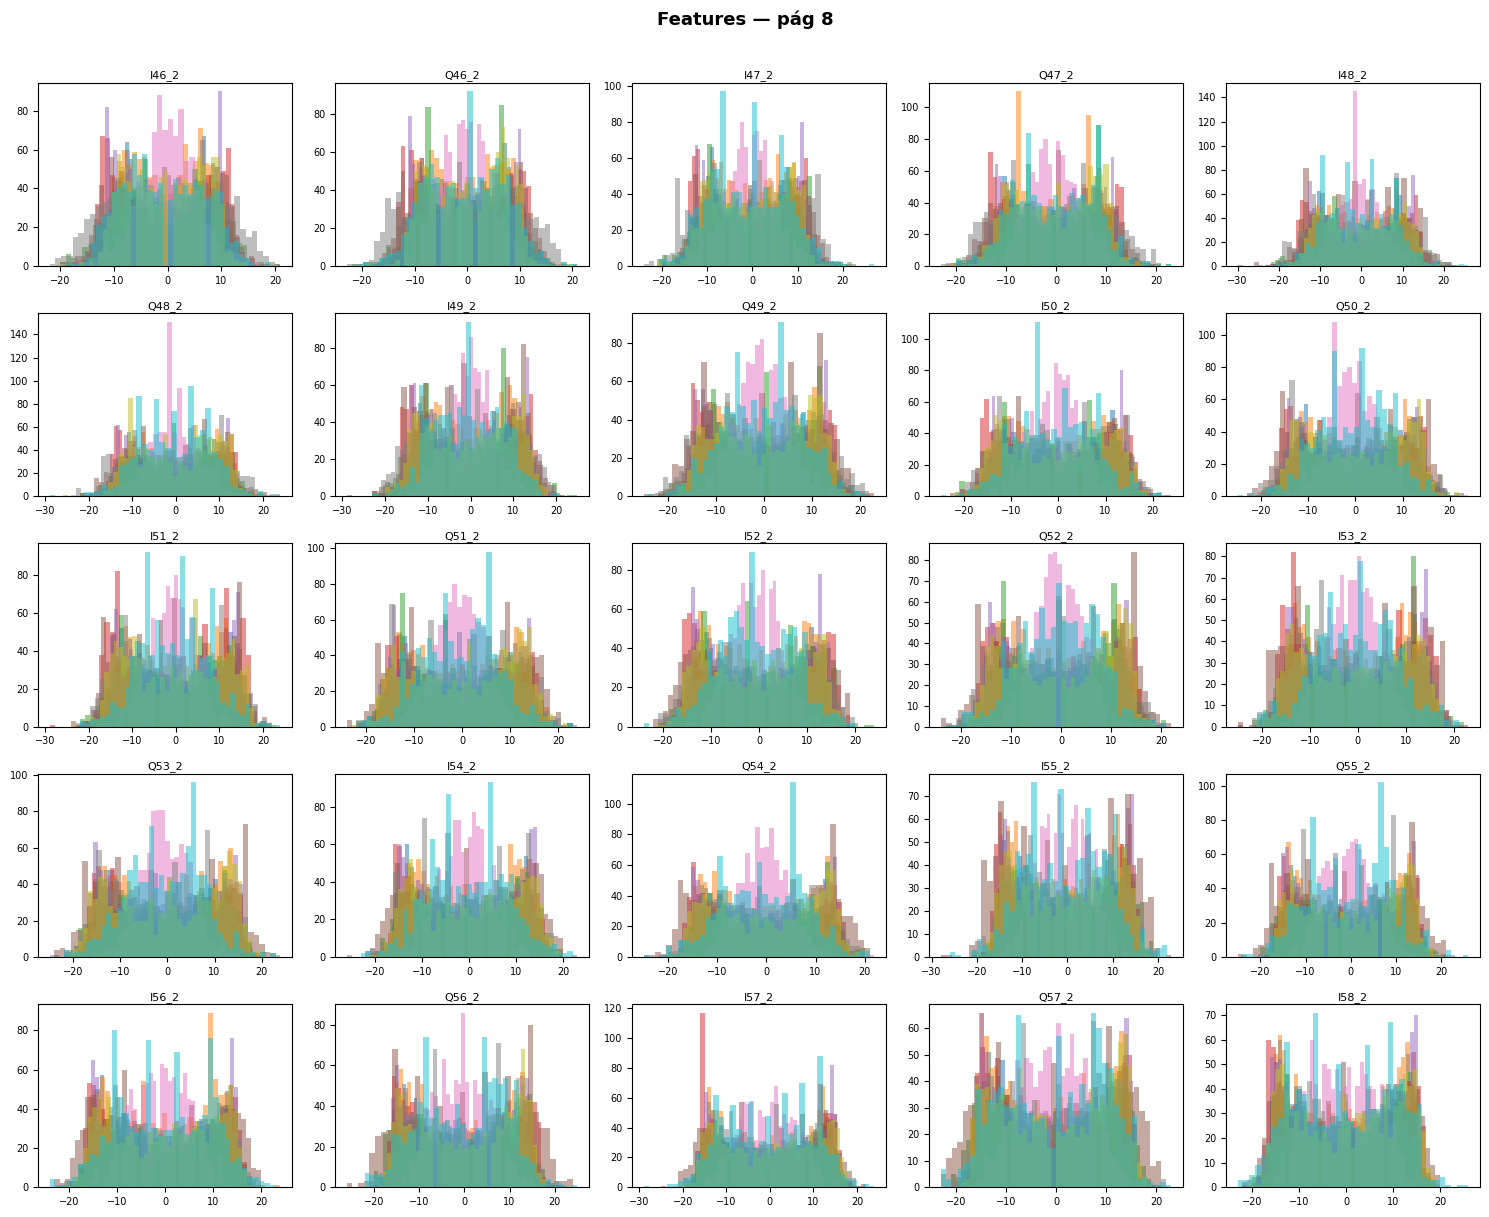

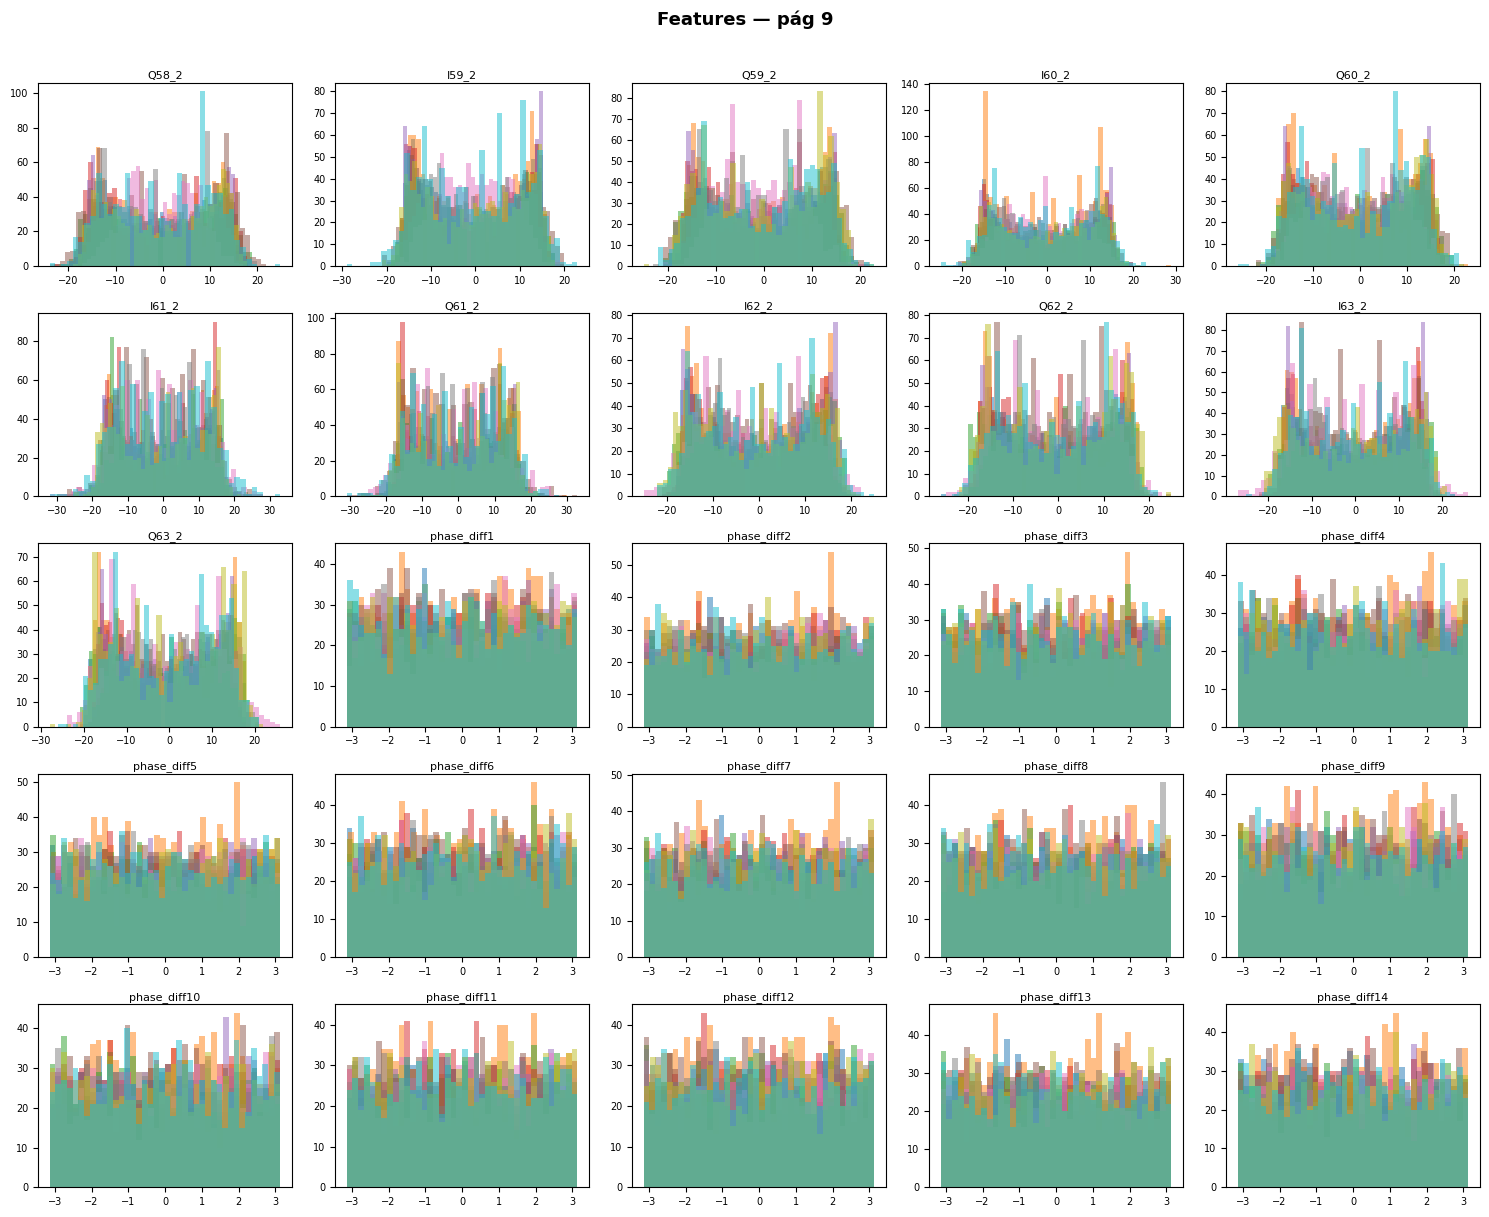

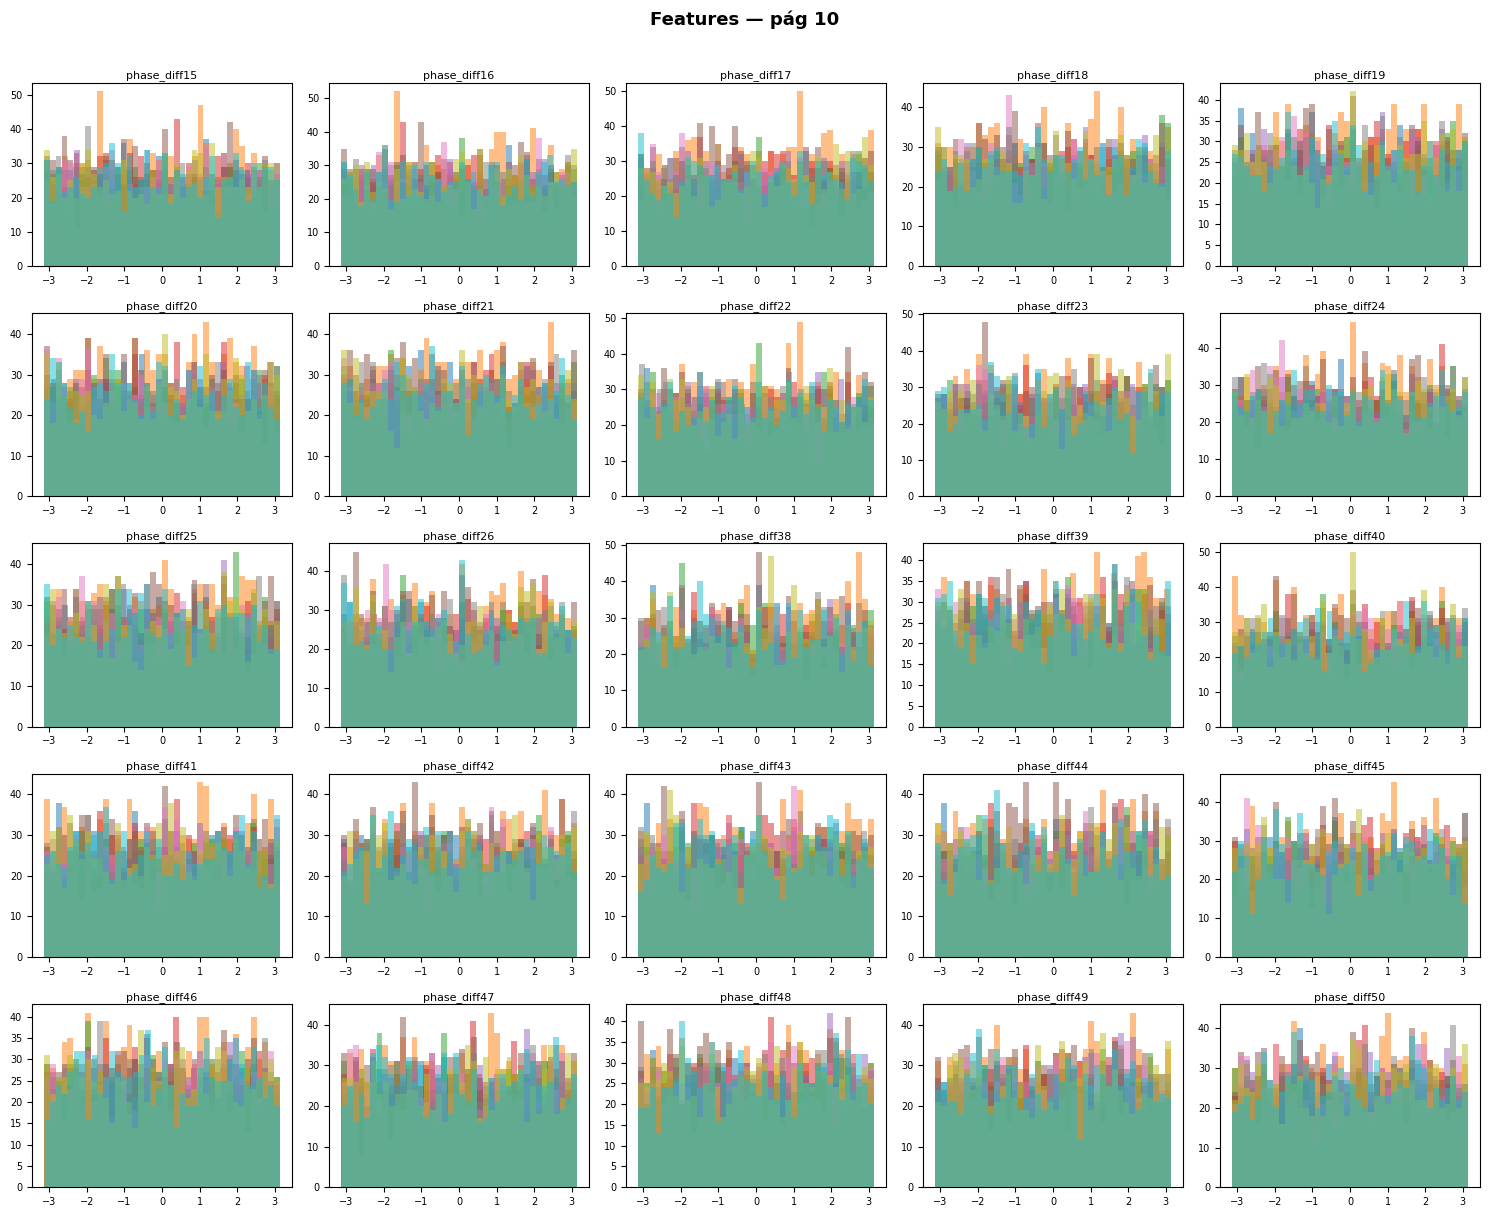

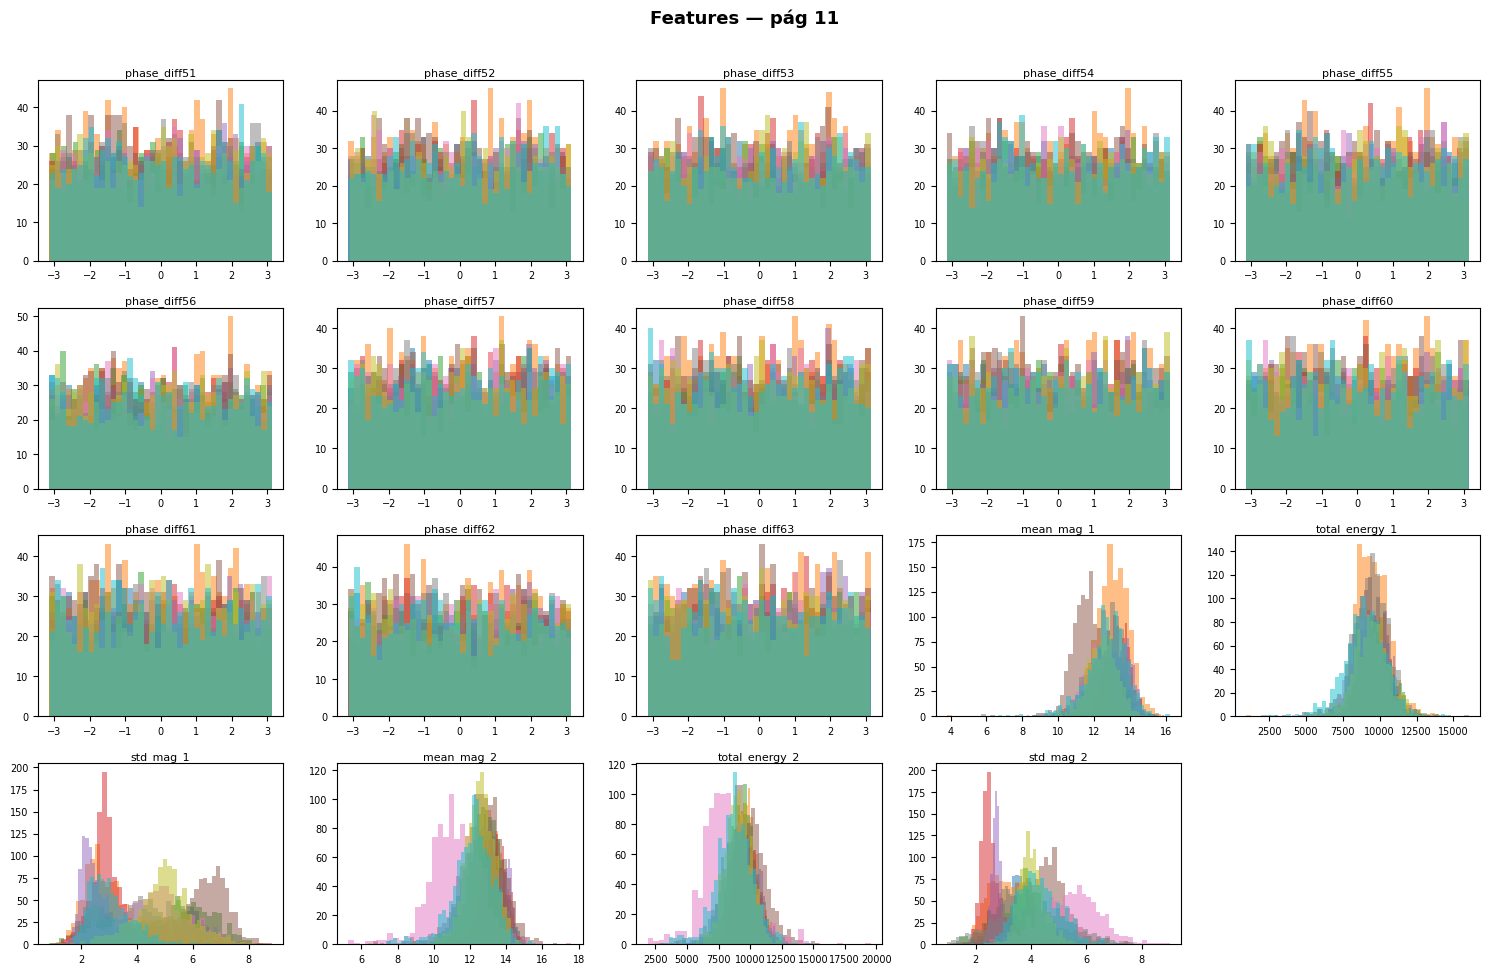

In [ ]:
# Ver en pantalla
#plot_feature_histograms(X_train_filtered)

# Colorear por clase
#plot_feature_histograms(pd.concat([X_train_filtered, y_train_filtered], axis=1), by_class=True)

# Guardar PNGs
#plot_feature_histograms(X_train_filtered, output_dir="plots/")

# NORMALIZACIÓN DE LOS DATOS

MODELOS COMO KNN MISMO ESCALADO PARA HACER BIEN LOS CÁLCULOS DE LA DISTANCIA (NO DAR MÁS PESO A NINGUNA FEATURE)

Magnitudes (CSI) aprox 100: RobustScaler o StandardScaler
Por qué: El RobustScaler es ideal si detectas que hay valores extremos (outliers) que "estiran" mucho el histograma hacia la derecha, ya que utiliza la mediana y el rango intercuartílico en lugar de la media. Si después de limpiar los outliers las distribuciones parecen más estables, el StandardScaler (media 0, varianza 1) funcionará perfectamente para modelos como SVM o Redes Neuronales.

aoa: StandardScaler
Por qué: Al ser una distribución tan simétrica y similar a una Normal, el StandardScaler es el método más eficiente para centrarla y reducir su escala sin perder la relación angular que representa

rssi1 y rssi2: MinMaxScaler (rango 0 a 1) o StandardScaler
Por qué: El MinMaxScaler es muy útil aquí para transformar esos valores negativos a un rango positivo fácil de procesar para cualquier modelo. Sin embargo, si vas a usar un modelo de distancias como KNN, asegúrate de usar el mismo escalado que en las magnitudes para que el RSSI no pierda peso.

seq_ctrl: No escalar o eliminar.
Por qué: Según la guía, seq_ctrl es solo un número de secuencia. Si decides incluirlo, usa un escalado robusto, pero ten en cuenta que en problemas de localización física, el número de secuencia suele ser ruido que no ayuda a predecir la posición a menos que haya un sesgo temporal en la captura.


## CSI:

## I i Q:

In [38]:
scaler_std = preprocessing.StandardScaler()
phase_diff_cols = [c for c in X_train_filtered.columns if 'I' in c or 'Q' in c]
X_train_filtered[phase_diff_cols] = scaler_std.fit_transform(X_train_filtered[phase_diff_cols])
X_test[phase_diff_cols] = scaler_std.transform(X_test[phase_diff_cols])
X_test_nolabels[phase_diff_cols] = scaler_std.transform(X_test_nolabels[phase_diff_cols])

## DIff de fase:

In [39]:
scaler= preprocessing.MinMaxScaler()
phase_diff_cols = [c for c in X_train_filtered.columns if 'phase_diff' in c]
X_train_filtered[phase_diff_cols] = scaler.fit_transform(X_train_filtered[phase_diff_cols])
X_test[phase_diff_cols] = scaler.transform(X_test[phase_diff_cols])
X_test_nolabels[phase_diff_cols] = scaler.transform(X_test_nolabels[phase_diff_cols])

## Features estadístiques (magnitud):

In [40]:
features = ['mean_mag_1', 'total_energy_1', 'std_mag_1', 'mean_mag_2', 'total_energy_2', 'std_mag_2']
col_magnitud = [col for col in X_train_filtered.columns if col not in features]

scaler = preprocessing.RobustScaler()

X_train_filtered[col_magnitud] = scaler.fit_transform(X_train_filtered[col_magnitud])
X_test[col_magnitud] = scaler.transform(X_test[col_magnitud])
X_test_nolabels[col_magnitud] = scaler.transform(X_test_nolabels[col_magnitud])

## aoa

In [41]:
scaler = preprocessing.MinMaxScaler(feature_range=(-1, 1))
X_train_filtered["aoa"] = scaler.fit_transform(X_train_filtered[["aoa"]])
X_test["aoa"] = scaler.transform(X_test[["aoa"]])
X_test_nolabels["aoa"] = scaler.transform(X_test_nolabels[["aoa"]])

array([<Axes: title={'center': 'aoa'}>], dtype=object)

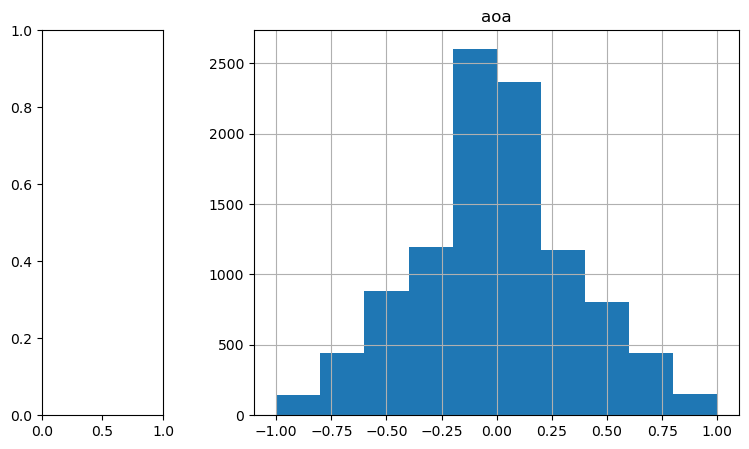

In [42]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.hist(column='aoa', ax=axes[1])

## rssi1 y rssi2:

In [43]:
scaler = preprocessing.StandardScaler()
X_train_filtered[["rssi1","rssi2"]] = scaler.fit_transform(X_train_filtered[["rssi1","rssi2"]])
X_test[["rssi1","rssi2"]] = scaler.transform(X_test[["rssi1","rssi2"]])
X_test_nolabels[["rssi1","rssi2"]] = scaler.transform(X_test_nolabels[["rssi1","rssi2"]])

array([<Axes: title={'center': 'rssi1'}>], dtype=object)

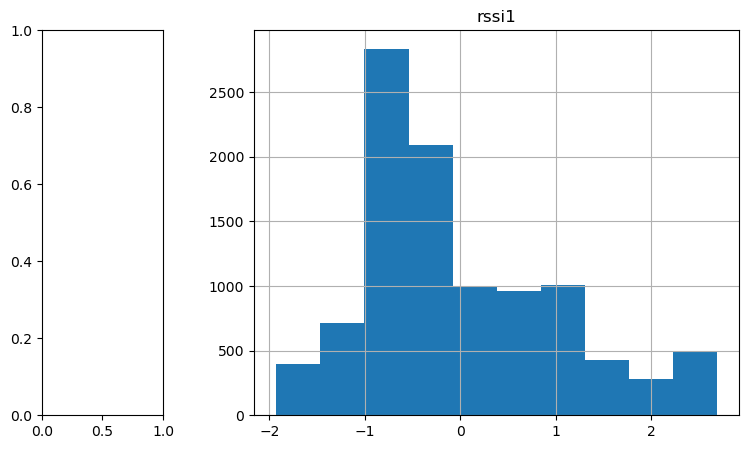

In [44]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.hist(column='rssi1', ax=axes[1])

array([<Axes: title={'center': 'rssi2'}>], dtype=object)

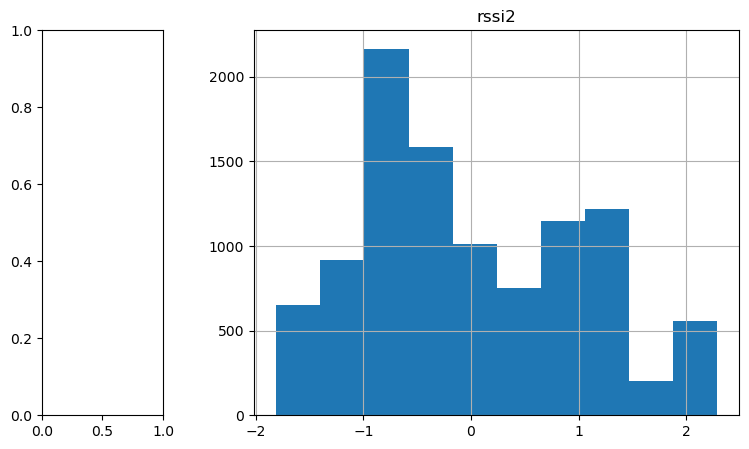

In [74]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.hist(column='rssi2', ax=axes[1])

In [45]:
X_train_filtered.shape, y_train_filtered.shape

((10210, 269), (10210,))

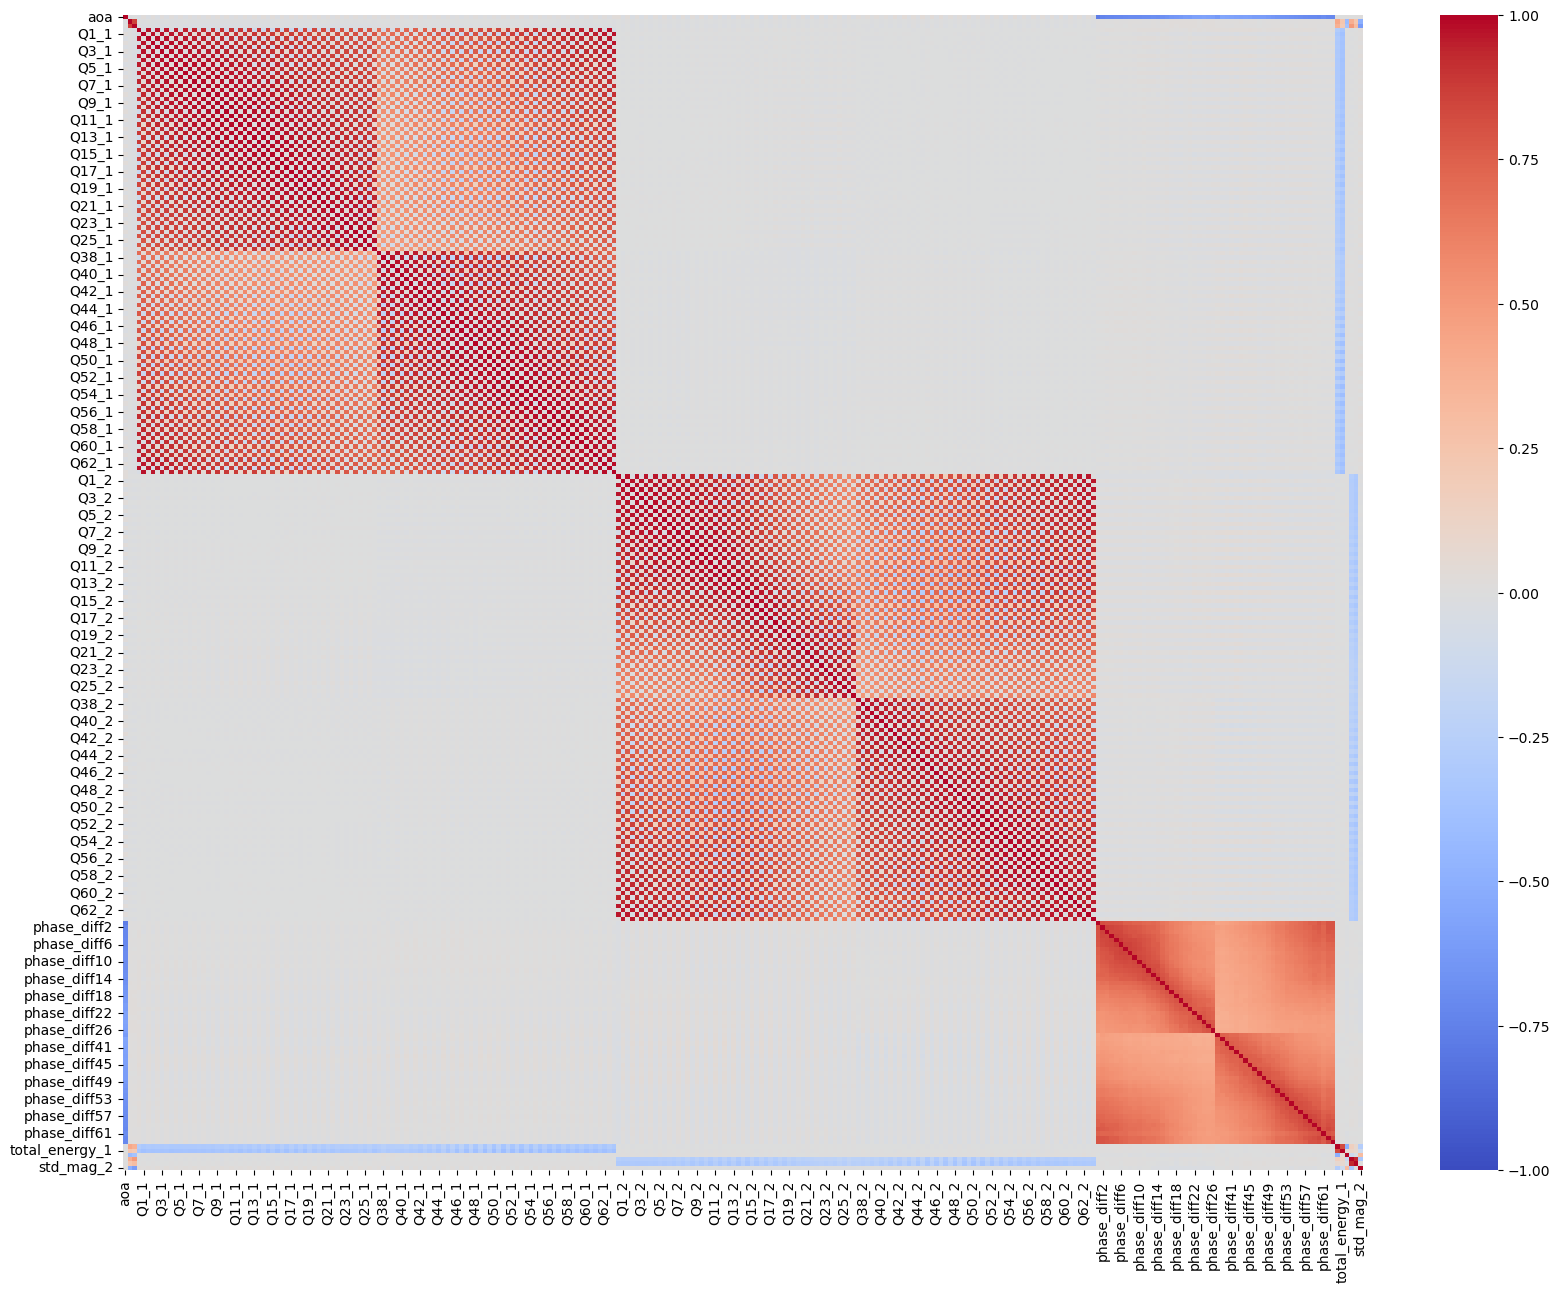

In [46]:
import seaborn

matriz_corr = X_train_filtered.corr()
plt.figure(figsize=(20, 15))
seaborn.heatmap(matriz_corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

c:\Users\dijor\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\dijor\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


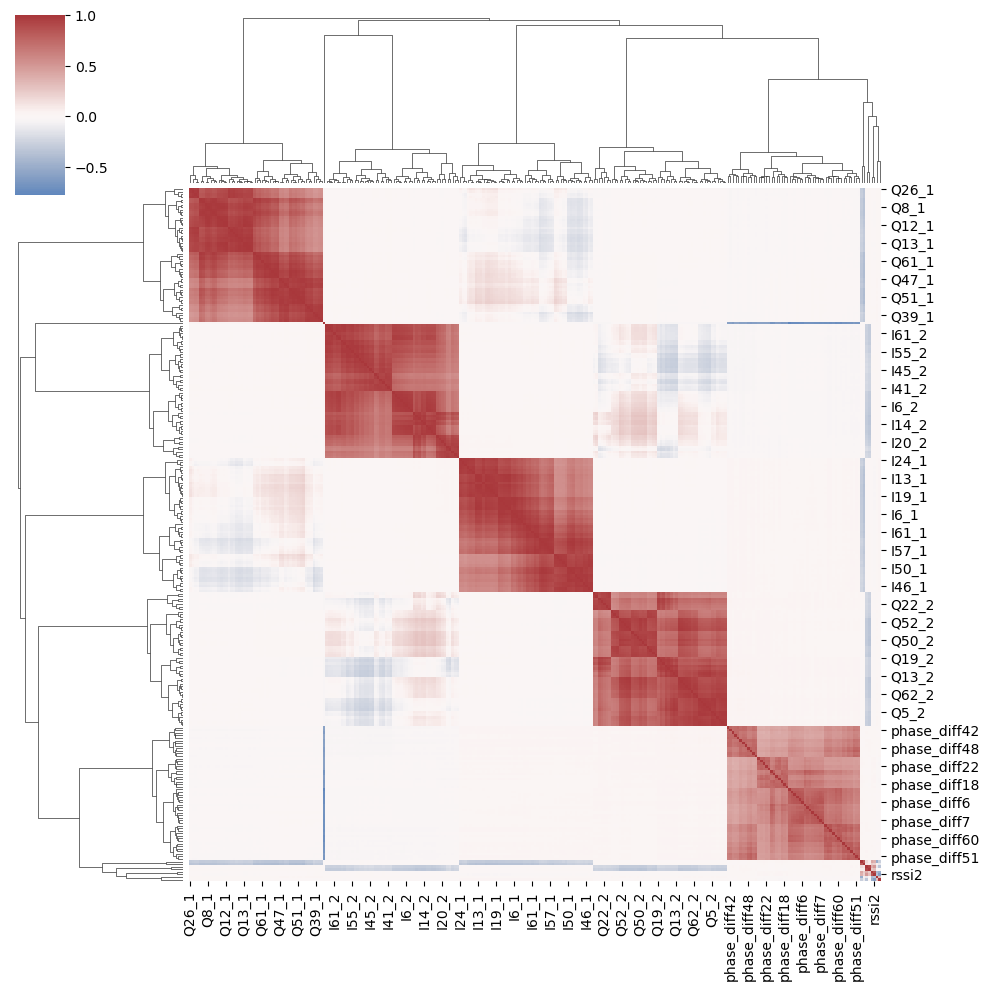

In [47]:
seaborn.clustermap(X_train_filtered.corr(), annot=False, cmap='vlag', center=0)
plt.show()

In [49]:
corr_aoa = matriz_corr['aoa'].sort_values(ascending=False)
print(corr_aoa)

aoa            1.000
I43_2          0.034
I47_2          0.033
I50_2          0.032
I42_2          0.032
               ...  
phase_diff6   -0.719
phase_diff4   -0.726
phase_diff3   -0.726
phase_diff2   -0.732
phase_diff1   -0.779
Name: aoa, Length: 269, dtype: float64


In [50]:
corr_rssi1 = matriz_corr['rssi1'].sort_values(ascending=False)
print(corr_rssi1)

rssi1             1.000
rssi2             0.852
mean_mag_1        0.422
mean_mag_2        0.386
total_energy_2    0.240
                  ...  
Q59_2            -0.015
Q46_2            -0.015
Q60_2            -0.016
std_mag_1        -0.419
std_mag_2        -0.493
Name: rssi1, Length: 269, dtype: float64


In [51]:
corr_rssi2 = matriz_corr['rssi2'].sort_values(ascending=False)
print(corr_rssi2)

rssi2             1.000
rssi1             0.852
mean_mag_2        0.499
mean_mag_1        0.367
total_energy_2    0.304
                  ...  
I22_1            -0.030
I12_1            -0.030
I15_1            -0.031
std_mag_1        -0.362
std_mag_2        -0.611
Name: rssi2, Length: 269, dtype: float64


In [53]:
X_train_filtered.to_csv('../data/processed/train_lof_features3_scaling.csv', index=False)
X_test.to_csv('../data/processed/test_lof_features3_scaling.csv', index=False)

y_train_filtered.to_csv('../data/processed/y_train_lof_features3_scaling.csv', index=False)
y_test.to_csv('../data/processed/y_test_lof_features3_scaling.csv', index=False)

X_test_nolabels.to_csv('../data/processed/test_nolabels_lof_features3_scaling.csv', index=False)
